<a href="https://colab.research.google.com/github/mehek-niwas/openvla-selfie/blob/main/selfie_vanilla_llama_7b_working_ver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Sat Sep  5 20:58:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             48W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [2]:
!pip install -q transformers accelerate sentencepiece

In [1]:
import torch, numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer
from IPython.display import HTML, display

DEVICE = "cuda"
DTYPE  = torch.float16

# Paper uses LLaMA-2-70B-Chat. 7B is much weaker at following the interpretation
# instruction (paper reports 27.17% failures for 7B vs 3.84% for 70B) -> noisier output.
MODEL = "NousResearch/Llama-2-7b-chat-hf"   # ungated mirror of meta-llama/Llama-2-7b-chat-hf

tok = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForCausalLM.from_pretrained(
    MODEL, torch_dtype=DTYPE, low_cpu_mem_usage=True,
    attn_implementation="eager",
).to(DEVICE).eval()

N_LAYERS = model.config.num_hidden_layers
print(f"{MODEL} | layers: {N_LAYERS} | hidden: {model.config.hidden_size}")

config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/746 [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

NousResearch/Llama-2-7b-chat-hf | layers: 32 | hidden: 4096


In [2]:
# Paper §4.1: interpretation prompt is
#   [INST] [X] [/INST] Sure, I'll summarize your message:
# with [X] repeated 5x, all 5 replaced by the SAME embedding, injected at layer k=3.
N_PLACEHOLDERS = 5
INJECT_LAYER   = 3      # paper's k

# Placeholder token identity barely matters: injection at layer 3 overwrites it
# before the suffix tokens can build any interpretation of it.
PH_ID = tok.encode("_", add_special_tokens=False)[-1]

PRE  = tok.encode("[INST] ", add_special_tokens=True)          # includes BOS
POST = tok.encode(" [/INST] Sure, I'll summarize your message:", add_special_tokens=False)

INTERP_IDS = PRE + [PH_ID] * N_PLACEHOLDERS + POST
SLOTS      = list(range(len(PRE), len(PRE) + N_PLACEHOLDERS))

print(f"{len(INTERP_IDS)} tokens, slots at {SLOTS}")
print(repr(tok.decode(INTERP_IDS)))

24 tokens, slots at [5, 6, 7, 8, 9]
"<s> [INST]  _ _ _ _ _ [/INST] Sure, I'll summarize your message:"


In [3]:
# Paper indexes h^0 = embedding output, h^l = output of layer l (1-indexed).
# HF: out.hidden_states[l] matches that exactly. Injecting "at layer k" means
# setting h^k, i.e. hooking the output of model.model.layers[k-1].
def layer_module(k):
    assert 1 <= k <= N_LAYERS, "k is 1-indexed (paper convention)"
    return model.model.layers[k - 1]

def make_inject_hook(vecs, slots):
    # vecs: (B, hidden) — one vector per batch item, broadcast across all slots
    def f(mod, inp, out):
        h = out[0] if isinstance(out, tuple) else out
        if h.shape[1] <= 1:              # KV-cached decode step: placeholders already cached
            return out
        h[:, slots, :] = vecs[:, None, :].to(h.dtype)
        return out
    return f

@torch.no_grad()
def interpret(vecs, k=INJECT_LAYER, max_new_tokens=24, bs=16, return_ids=False):
    """vecs: (N, hidden). Returns list of strings (or list of token-id lists)."""
    if vecs.dim() == 1:
        vecs = vecs[None]
    texts, id_lists = [], []
    for i in range(0, len(vecs), bs):
        b   = vecs[i:i+bs].to(DEVICE, dtype=DTYPE)
        ids = torch.tensor([INTERP_IDS] * len(b), device=DEVICE)
        h   = layer_module(k).register_forward_hook(make_inject_hook(b, SLOTS))
        try:
            g = model.generate(ids, max_new_tokens=max_new_tokens, do_sample=False,
                               pad_token_id=tok.eos_token_id)
        finally:
            h.remove()
        new = g[:, len(INTERP_IDS):]
        id_lists += [[t for t in row.tolist() if t != tok.eos_token_id] for row in new]
        texts    += [s.strip() for s in tok.batch_decode(new, skip_special_tokens=True)]
    return (texts, id_lists) if return_ids else texts

@torch.no_grad()
def hidden_states(prompt):
    """Returns (H, tokens). H[l] = h^l, shape (seq, hidden), l = 0..N_LAYERS."""
    ids = tok(prompt, return_tensors="pt").input_ids.to(DEVICE)
    out = model(input_ids=ids, output_hidden_states=True)
    H = torch.stack([h[0].float().cpu() for h in out.hidden_states])
    return H, [tok.decode([t]) for t in ids[0].tolist()]

In [4]:
H_c, toks_c = hidden_states("The yellow corn sat on the table beside a blue cup.")
pick = [i for i, s in enumerate(toks_c) if s.strip() in ("corn", "table", "cup", "yellow")]
print("probing:", [toks_c[i] for i in pick], "\n")

for l in [4, 8, 16, 24]:
    print(f"--- source layer {l} (injected at k={INJECT_LAYER}) ---")
    for i, o in zip(pick, interpret(H_c[l][pick], max_new_tokens=20)):
        print(f"  {toks_c[i]!r:>10} -> {o}")
    print()

[transformers] The attention mask is not set with a batched input, and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


probing: ['yellow', 'corn', 'table', 'cup'] 

--- source layer 4 (injected at k=3) ---
    'yellow' -> You would like to know the meaning of the word "yellow" in different contexts.
      'corn' -> You are interested in learning more about corn, specifically the type of corn called "corn
     'table' -> You want to know how to make a table that is also a table. Is that correct
       'cup' -> You want to know how to make a cup of tea using a cup and a teap

--- source layer 8 (injected at k=3) ---
    'yellow' -> You want to know the meaning of the word "yellow" in different contexts.
      'corn' -> You are asking for information on the nutritional value of corn, specifically the nutr
     'table' -> There is a table in the room, and on the table there is a collection of objects
       'cup' -> You have a cup with a capacity of 8 ounces (0.5 lit

--- source layer 16 (injected at k=3) ---
    'yellow' -> You mentioned that you want to know the meaning of the color yellow or yellowish i

In [5]:
ORIG_PROMPT = "[INST] What is the tallest mountain in the world? [/INST]"

ids = tok(ORIG_PROMPT, return_tensors="pt").input_ids.to(DEVICE)
with torch.no_grad():
    ans = model.generate(ids, max_new_tokens=40, do_sample=False,
                         pad_token_id=tok.eos_token_id)
print("model answer:", tok.decode(ans[0, ids.shape[1]:], skip_special_tokens=True).strip())

H, toks = hidden_states(ORIG_PROMPT)
print("\nH:", tuple(H.shape), "(layers+1, seq, hidden)")
for i, t in enumerate(toks):
    print(f"  {i:>2} {t!r}")

model answer: The tallest mountain in the world is Mount Everest, located in the Himalayas on the border between Nepal and Tibet, China. It stands at an elevation of

H: (33, 18, 4096) (layers+1, seq, hidden)
   0 '<s>'
   1 '['
   2 'INST'
   3 ']'
   4 'What'
   5 'is'
   6 'the'
   7 'tall'
   8 'est'
   9 'mountain'
  10 'in'
  11 'the'
  12 'world'
  13 '?'
  14 '['
  15 '/'
  16 'INST'
  17 ']'


In [6]:
POSITIONS = list(range(len(toks) - 6, len(toks)))    # last 6 tokens
LAYERS    = list(range(0, N_LAYERS + 1, 2))

grid = {}
for l in LAYERS:
    outs = interpret(H[l][POSITIONS], max_new_tokens=20)
    grid[l] = outs
    for p, o in zip(POSITIONS, outs):
        hit = "*" if "everest" in o.lower() else " "
        print(f"{hit} L{l:>2} {toks[p]!r:>12} -> {o}")
    print()

n_hits = sum("everest" in o.lower() for outs in grid.values() for o in outs)
print(f"\n'Everest' recalled in {n_hits} / {len(LAYERS)*len(POSITIONS)} interpretations")

  L 0      'world' -> As a responsible and ethical AI language model, I will provide you with a compreh
  L 0          '?' -> * FARING:
* FARMING:
* FARMING
  L 0          '[' -> 1. "The best":

* Haha]

1. Good luck
  L 0          '/' -> In the first place, I’ll talk about the things that make sense, and then
  L 0       'INST' -> I'm just an AI model, not a human. I don't have
  L 0          ']' -> * * *

This is the command I've been given.')

  L 2      'world' -> The world is a wonderful place full of diverse cultures, languages, and beliefs.
  L 2          '?' -> You are asking for help with a task, but you are not providing enough information for me
  L 2          '[' -> You have a blank space and you want to know how to fill it.

Is
  L 2          '/' -> You have a forward slash (/) in your message, which is a common character used in
  L 2       'INST' -> You want to know if it's possible to create a chatbot that can understand and
  L 2          ']' -> You have asked me to wr

In [7]:
@torch.no_grad()
def relevancy(vec, gen_ids, k=INJECT_LAYER):
    """rel(t_i) = P[t_i | I, t_<i, h] - P[t_i | I, t_<i]  (paper §3.2)"""
    full = torch.tensor([INTERP_IDS + gen_ids], device=DEVICE)
    v    = vec[None].to(DEVICE, dtype=DTYPE)

    h = layer_module(k).register_forward_hook(make_inject_hook(v, SLOTS))
    try:    lg_with = model(input_ids=full).logits[0].float()
    finally: h.remove()
    lg_without = model(input_ids=full).logits[0].float()

    n, scores = len(INTERP_IDS), []
    for i, t in enumerate(gen_ids):
        pos = n + i - 1
        p_w  = lg_with[pos].softmax(-1)[t].item()
        p_wo = lg_without[pos].softmax(-1)[t].item()
        scores.append((tok.decode([t]), p_w - p_wo))
    return scores

def show_relevancy(scores):
    mx = max(abs(s) for _, s in scores) or 1.0
    html = "".join(
        f"<span style='background:rgba(255,90,0,{abs(s)/mx:.3f});padding:1px'>"
        f"{t.replace('<','&lt;')}</span>" for t, s in scores)
    display(HTML(f"<div style='font-family:monospace;font-size:14px'>{html}</div>"))

# pick a layer/position whose interpretation mentioned Everest
SRC_LAYER, SRC_POS = 12, len(toks) - 1        # <- adjust from Cell 7's output

txt, gen = interpret(H[SRC_LAYER][SRC_POS], max_new_tokens=24, return_ids=True)
print(f"L{SRC_LAYER} {toks[SRC_POS]!r} -> {txt[0]}\n")

sc = relevancy(H[SRC_LAYER][SRC_POS], gen[0])
show_relevancy(sc)
for t, s in sc:
    print(f"  {t!r:>14}  {s:+.4f}")

L12 ']' -> You are asking for a summary of your previous message, which was a question about how to get a summary of



            '\n'  -0.0099
            '\n'  +0.0002
           'You'  +0.1286
           'are'  +0.3261
        'asking'  +0.5028
           'for'  -0.2493
             'a'  +0.0800
       'summary'  +0.4749
            'of'  +0.0009
          'your'  +0.4401
      'previous'  +0.6638
       'message'  -0.0005
             ','  +0.0056
         'which'  -0.0216
           'was'  +0.4174
             'a'  +0.4113
      'question'  +0.6263
         'about'  +0.8043
           'how'  +0.4102
            'to'  +0.0102
           'get'  +0.0795
             'a'  +0.1839
       'summary'  +0.5919
            'of'  +0.0010


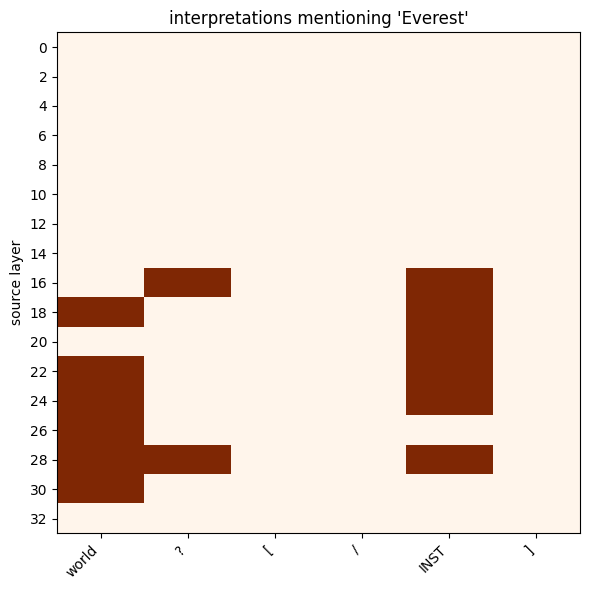

In [8]:
import matplotlib.pyplot as plt

M = np.zeros((len(LAYERS), len(POSITIONS)))
for li, l in enumerate(LAYERS):
    for pi, o in enumerate(grid[l]):
        M[li, pi] = "everest" in o.lower()

plt.figure(figsize=(6, 6))
plt.imshow(M, aspect="auto", cmap="Oranges", vmin=0, vmax=1)
plt.yticks(range(len(LAYERS)), LAYERS); plt.ylabel("source layer")
plt.xticks(range(len(POSITIONS)), [toks[p] for p in POSITIONS], rotation=45, ha="right")
plt.title("interpretations mentioning 'Everest'"); plt.tight_layout(); plt.show()